# Test classification using Hagging Face Library

In [1]:
# Import libraries
from transformers import pipeline

In [2]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
# Import library
from transformers import pipeline

# Load the text generation pipeline with the specified model
pipeline = pipeline(task="text-generation", model="google/gemma-2-2b")

# Generate text based on the prompt
pipeline("the secret to baking a really good cake is ")

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2-2b.
403 Client Error. (Request ID: Root=1-68506fa0-422ce2ef4e6858cb255205da;bd1ac410-87d9-4d3c-bd5a-766dfdf5ec72)

Cannot access gated repo for url https://huggingface.co/google/gemma-2-2b/resolve/main/config.json.
Access to model google/gemma-2-2b is restricted and you are not in the authorized list. Visit https://huggingface.co/google/gemma-2-2b to ask for access.

In [4]:
import torch
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model="google/gemma-2-2b",
    device="cuda",  # replace with "mps" to run on a Mac device
)

text = "Once upon a time,"
outputs = pipe(text, max_new_tokens=256)
response = outputs[0]["generated_text"]
print(response)


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2-2b.
403 Client Error. (Request ID: Root=1-68506fef-008b0fd8119226cc1f7e8856;3d353768-1719-444a-aafa-11d11599ec12)

Cannot access gated repo for url https://huggingface.co/google/gemma-2-2b/resolve/main/config.json.
Access to model google/gemma-2-2b is restricted and you are not in the authorized list. Visit https://huggingface.co/google/gemma-2-2b to ask for access.

In [7]:
from transformers import pipeline

# One-liner sentiment analysis
classifier = pipeline(
    task='text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
)

text = [
    'I love using Hugging Face Transformers!',
    'I am not a fan of the new design.',
    'The weather is great today.',
    'I am feeling sad about the news.',
]
print(classifier(text))



Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9971315860748291}, {'label': 'NEGATIVE', 'score': 0.991818904876709}, {'label': 'POSITIVE', 'score': 0.9998729228973389}, {'label': 'NEGATIVE', 'score': 0.9985436201095581}]


In [12]:
from transformers import pipeline

# One-liner sentiment analysis
classifier = pipeline(
    task='text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
)

# read csv file of comments and run the classifier
import pandas as pd
df = pd.read_csv('youtube analysis.csv')
text = df['analysis'].tolist()
results = classifier(text)
# Add the results to the dataframe
df['sentiment'] = [result['label'] for result in results]
# Save the dataframe to a new csv file
df.to_csv('youtub analysis with sentiment.csv', index=False)
df.head()

Device set to use cpu


,analysis,sentiment
0,Subscribe the channel for more cricket videos.,NEGATIVE
1,Allah kry asa match dobara dakhna naseeb ho......,NEGATIVE
2,Who is watching for king Amir,POSITIVE
3,This is an unforgettable match between Pak vs ...,POSITIVE
4,Pakistan Zindabad Bohat He Panta Lagayan Hai I...,POSITIVE


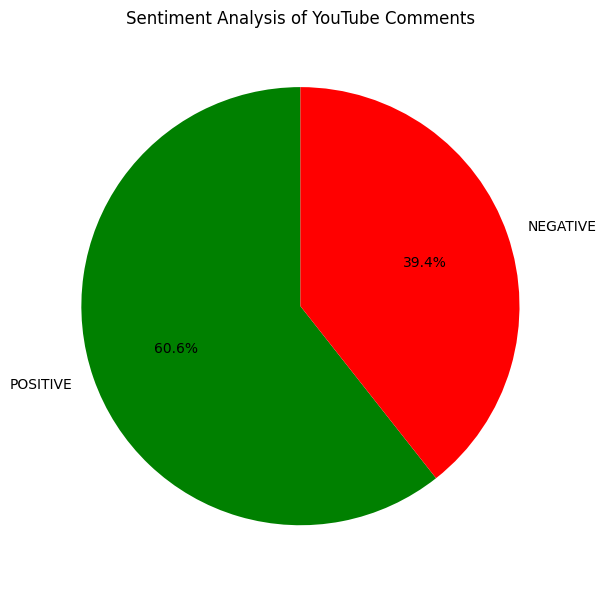

In [18]:
import matplotlib.pyplot as plt

# Count the number of positive and negative sentiments
sentiment_counts = df['sentiment'].value_counts()

# Plot the sentiment counts
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'], startangle=90, legend=False)
plt.ylabel('')
plt.title('Sentiment Analysis of YouTube Comments')
plt.tight_layout()
plt.show()
